# Building the NLA Response One Factor at a Time

The previous notebook used **PyCCL** to define a cosmology and calculate the matter
power spectrum. This notebook now focuses on the multiplicative factors that control
the nonlinear-alignment (NLA) response. Studying them separately makes their physical
roles, limiting behavior, and parameter degeneracies easier to understand.

## The path through the notebook

By the end, you should be able to:

- explain why a tidal gravitational field can influence galaxy orientations;
- distinguish the linear-alignment and nonlinear-alignment prescriptions;
- decompose the NLA response into cosmological, redshift, luminosity, and scale factors;
- interpret every parameter from plots of its individual factor;
- verify the normalization and asymptotic limits of the phenomenological extensions.

The workflow continues in two separate notebooks: `POWER.ipynb` combines the factors
and constructs IA power spectra, while `SAMPLE.ipynb` samples the model parameters and
builds datasets.

The luminosity and scale-dependent extensions introduced here are deliberately
**phenomenological**. They are useful for teaching and flexible forward modelling, but
they do not replace a survey-calibrated luminosity model or the TATT framework.

---

## Why galaxies can become intrinsically aligned

A galaxy forms inside the cosmic web. Gravity does not pull equally strongly in every
direction: nearby matter can stretch the local gravitational environment more along one
direction than another. This directional stretching is called the **tidal field**.

A simple intrinsic-alignment hypothesis is:

> The coherent part of a galaxy's intrinsic shape responds to the surrounding tidal field.

We summarize that response with an IA amplitude $F$:

$$
\text{intrinsic shape} \approx F \times \text{matter tidal field}.
$$

If the matter field has power spectrum $P_{\rm m}$, this response produces

$$
P_{\delta I}(k,z)=F(k,z)\,P_{\rm m}(k,z),
\qquad
P_{II}(k,z)=F^2(k,z)\,P_{\rm m}(k,z).
$$

- $P_{\delta I}$ correlates matter density with intrinsic galaxy shape.
- $P_{II}$ correlates two intrinsic-shape fields.

Under the sign convention used here, positive $A_0$ gives negative
$P_{\delta I}$, while $P_{II}$ remains non-negative.

### From linear alignment to nonlinear alignment

In the **linear-alignment (LA)** model, the IA response multiplies the linear matter
power spectrum:

$$
P_{\delta I}^{\rm LA}=F\,P_{\rm lin},
\qquad
P_{II}^{\rm LA}=F^2\,P_{\rm lin}.
$$

The **nonlinear-alignment (NLA)** prescription keeps the same response structure but
replaces the linear spectrum with the nonlinear matter spectrum:

$$
P_{\delta I}^{\rm NLA}=F\,P_{\rm nl},
\qquad
P_{II}^{\rm NLA}=F^2\,P_{\rm nl}.
$$

NLA is a useful empirical baseline rather than a complete theory of nonlinear galaxy
formation. More advanced models, such as TATT, introduce additional tidal-field terms.

---

## Decompose the NLA response

We write the response as

$$
\boxed{
F(k,z)=
-A_0\,
F_\Omega(z)\,
R_z(z;\eta,z_p)\,
R_L(z;\xi,s,z_q)\,
S(k;q,n,k_t)
}
$$

with the standard cosmological scaling

$$
F_\Omega(z)=C_0\frac{\Omega_m}{D(z)}.
$$

| Factor | Role |
|---|---|
| $A_0$ | Overall IA strength and sign |
| $F_\Omega$ | Standard cosmological density and growth scaling |
| $R_z$ | Additional physical redshift evolution |
| $R_L$ | Effective luminosity-population evolution |
| $S(k)$ | Phenomenological scale dependence |

We normalize $R_z(z_p)=R_L(z_p)=1$ and have $S(k\ll k_t)=1$. These conventions
keep the factors interpretable before they are combined in `POWER.ipynb`.

---

## Set up the calculation

We use NumPy for numerical arrays, PyCCL for cosmological growth, and Matplotlib for
visualization. The plotting style is configured once and reused throughout the notebook.

In [1]:
import json
from pathlib import Path

import numpy
import pyccl
from matplotlib import pyplot

In [2]:
pyplot.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 25,
    "text.usetex": True,
})

In [3]:
base_path = Path.cwd().parent if Path.cwd().name == "Code" else Path.cwd()
data_path = base_path / "Data"

print("Project directory:", base_path)
print("Data directory:   ", data_path)

Project directory: /Users/s2227120/Downloads/IAFlowCloud
Data directory:    /Users/s2227120/Downloads/IAFlowCloud/Data


### Fix the cosmology and redshift grid

We keep the cosmology fixed so that changes in the following plots can be attributed to
one IA factor at a time. The parameters are read from `Planck.json`, and CAMB supplies
the transfer function and nonlinear matter prescription used by PyCCL.

PyCCL expects scale factor rather than redshift in its growth functions, so every
redshift array is converted using $a=1/(1+z)$.

In [4]:
with open(data_path / "Planck.json", "r", encoding="utf-8") as file:
    parameter = json.load(file)

print(parameter)

{'H': 0.6731999996749277, 'W0': -1.0, 'WA': 0.0, 'NS': 0.966, 'AS': 2.101e-09, 'MNU': 0.06, 'TCMB': 2.7255, 'NEFF': 3.0440016274835076, 'SIGMA8': 0.812, 'OMEGAM': 0.314419, 'OMEGAB': 0.04939, 'OMEGAC': 0.265029, 'OMEGAD': 0.68408, 'OMEGAN': 0.0014214549162596109, 'OMEGAR': 7.973409482179201e-05, 'OMEGAK': -1.8901108145286116e-07}


In [5]:
cosmology = pyccl.cosmology.Cosmology(
    h=parameter["H"],
    w0=parameter["W0"],
    wa=parameter["WA"],
    A_s=parameter["AS"],
    n_s=parameter["NS"],
    m_nu=parameter["MNU"],
    T_CMB=parameter["TCMB"],
    Omega_k=parameter["OMEGAK"],
    Omega_c=parameter["OMEGAC"],
    Omega_b=parameter["OMEGAB"],
    mass_split="normal",
    transfer_function="boltzmann_camb",
    extra_parameters={
        "camb": {
            "kmax": 100,
            "lmax": 5000,
            "halofit_version": "mead2020_feedback",
            "HMCode_logT_AGN": 7.8,
        }
    },
)

In [6]:
z1 = 0.0
z2 = 3.0
z_size = 10
z_grid = numpy.linspace(z1, z2, z_size)

---

## Standard cosmological scaling

The conventional NLA amplitude contains

$$
\boxed{
F_\Omega(z)=C_0\frac{\Omega_m}{D(z)},
}
$$

where $D(z)$ is the linear growth factor normalized to $D(0)=1$ and
$C_0\simeq0.0134$ is the conventional IA normalization. Because structure is less
developed at higher redshift, $D(z)$ decreases and $1/D(z)$ increases.

In [7]:
C0 = 0.0134


def cosmological_factor(cosmo, z, constant=C0):
    """
    Calculate the standard NLA cosmological factor.
    
    Arguments:
        cosmo (pyccl.Cosmology):
            Cosmology used to evaluate the linear growth factor and Omega_m.
        z (float, list, tuple, or numpy.ndarray):
            Redshift value or array. Every value must be greater than -1.
        constant (float or int):
            Conventional IA normalization. The default is C0 = 0.0134.
    
    Returns:
        factor (numpy.float64 or numpy.ndarray):
            The quantity constant * Omega_m / D(z), with the same shape as z.
    """
    z_array = numpy.asarray(z, dtype=float)
    
    if numpy.any(z_array <= -1.0):
        raise ValueError("All redshifts must satisfy z > -1.")
    
    a_array = 1.0 / (1.0 + z_array)
    growth = pyccl.growth_factor(cosmo, a_array)
    return constant * cosmo["Omega_m"] / growth


cosmological_factor_grid = cosmological_factor(cosmology, z_grid)

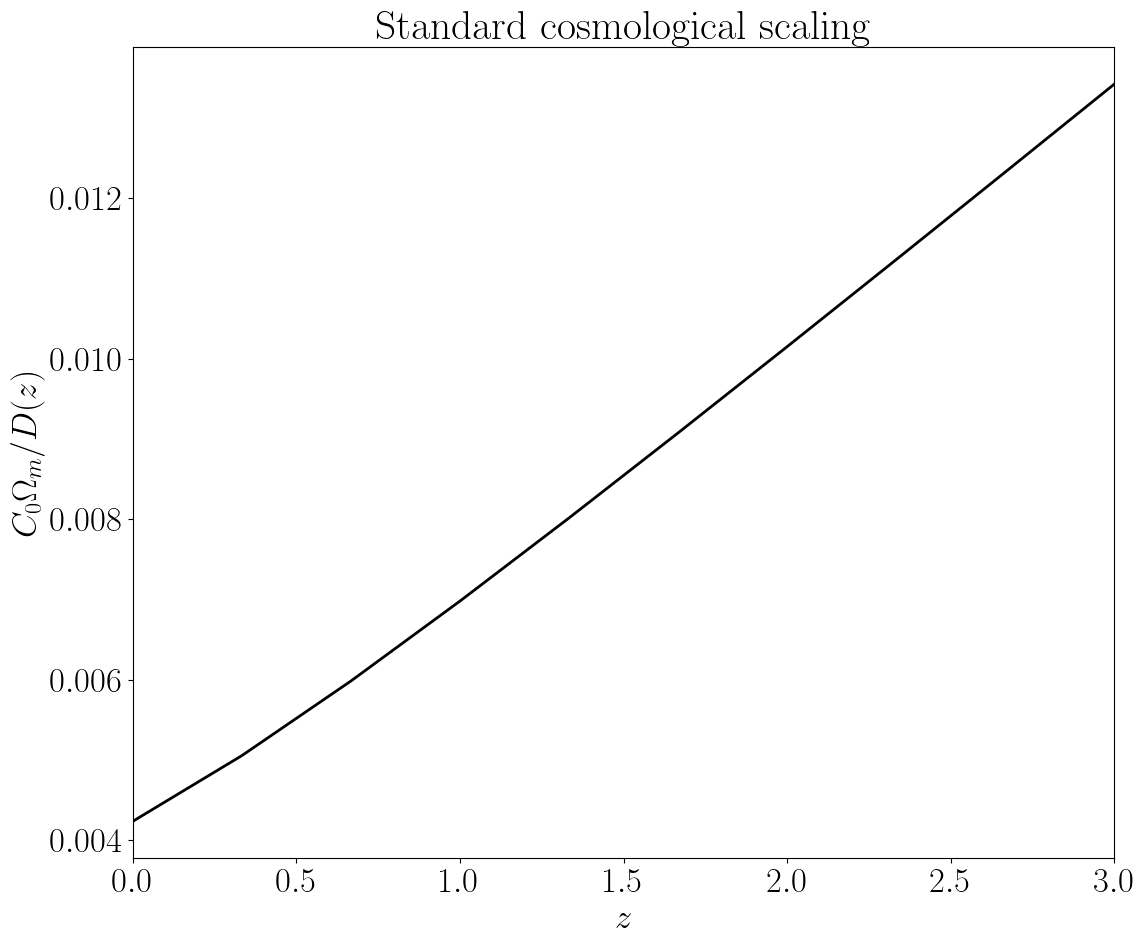

In [8]:
figure, plot = pyplot.subplots(figsize=(12, 10))

plot.plot(
    z_grid,
    cosmological_factor_grid,
    color="black",
    linewidth=2,
)

plot.set_xlim(z1, z2)
plot.set_xlabel(r"$z$")
plot.set_ylabel(r"$C_0\Omega_m/D(z)$")
plot.set_title("Standard cosmological scaling")

figure.tight_layout()
pyplot.show()

---

## Additional physical redshift evolution

The conventional growth factor already introduces redshift evolution. We allow an
additional empirical power law:

$$
\boxed{
R_z(z;\eta,z_p)
=
\left(\frac{1+z}{1+z_p}\right)^\eta.
}
$$

- $\eta=0$: no additional evolution;
- $\eta>0$: stronger response at high redshift;
- $\eta<0$: weaker response at high redshift.

The pivot $z_p$ only fixes the normalization: changing $\eta$ does not change the
factor at $z=z_p$.

In [9]:
Z_PIVOT = 0.5

def redshift_factor(z, eta=0.0, z_pivot=Z_PIVOT):
    """
    Calculate the normalized power-law redshift factor.
    
    Arguments:
        z (float, list, tuple, or numpy.ndarray):
            Redshift value or array. Every value must be greater than -1.
        eta (float or int):
            Additional power-law index controlling redshift evolution.
        z_pivot (float or int):
            Normalization pivot. It must be greater than -1.
    
    Returns:
        factor (numpy.float64 or numpy.ndarray):
            The normalized factor R_z(z; eta, z_p), with the same shape as z.
    """
    z_array = numpy.asarray(z, dtype=float)
    
    if numpy.any(z_array <= -1.0) or z_pivot <= -1.0:
        raise ValueError("Redshifts and z_pivot must satisfy z > -1.")
    
    return ((1.0 + z_array) / (1.0 + z_pivot))**eta

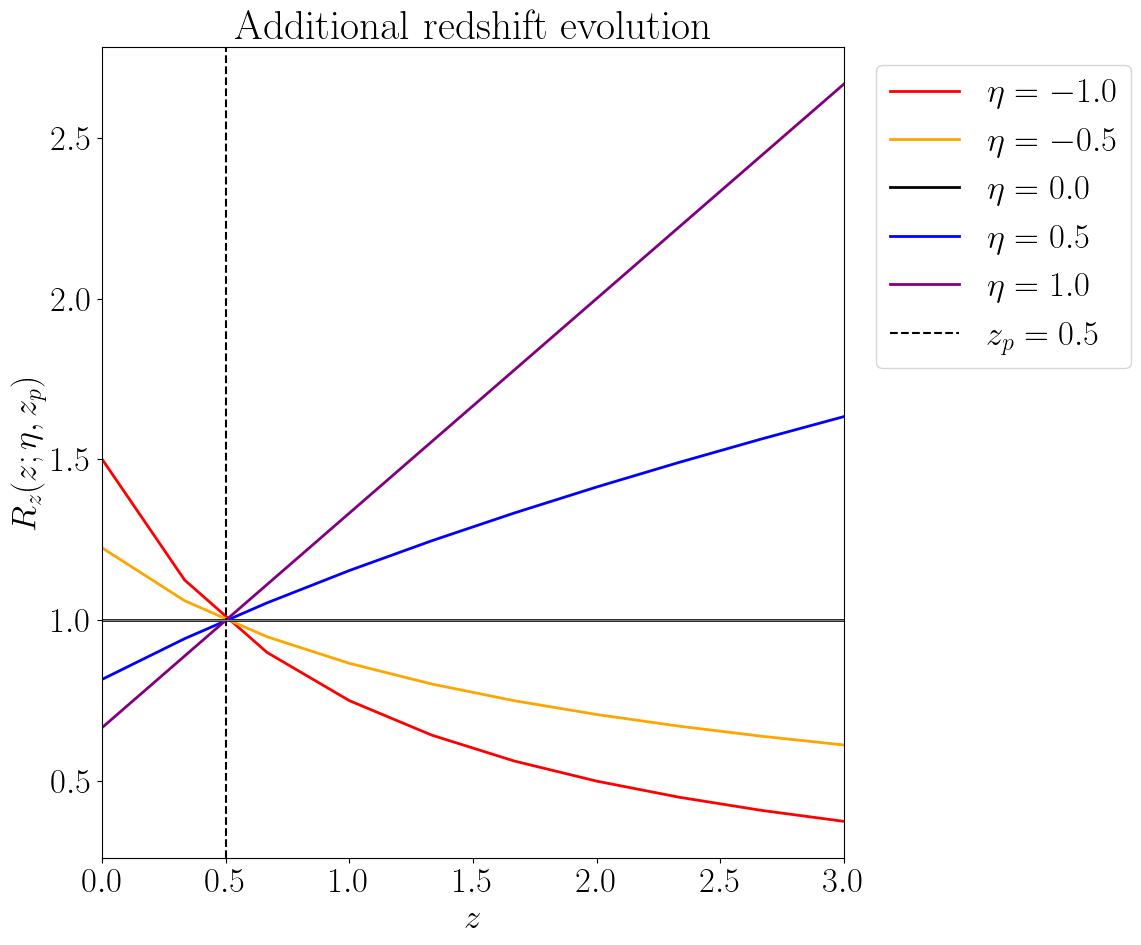

In [10]:
eta_list = [-1.0, -0.5, 0.0, 0.5, 1.0]
colour_list = ["red", "orange", "black", "blue", "purple"]

figure, plot = pyplot.subplots(figsize=(12, 10))

for eta, colour in zip(eta_list, colour_list):
    plot.plot(
        z_grid,
        redshift_factor(z_grid, eta=eta),
        color=colour,
        linewidth=2,
        label=rf"$\eta={eta}$",
    )

plot.axvline(
    Z_PIVOT,
    color="black",
    linestyle="--",
    label=rf"$z_p={Z_PIVOT}$",
)
plot.axhline(1.0, color="grey", linewidth=1)
plot.set_xlim(z1, z2)
plot.set_xlabel(r"$z$")
plot.set_ylabel(r"$R_z(z;\eta,z_p)$")
plot.set_title("Additional redshift evolution")
plot.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))

figure.tight_layout()
pyplot.show()

---

## Smooth luminosity-population evolution

Physically, the luminosity contribution is an average over the galaxies in a redshift
bin:

$$
R_L(z)\propto
\left\langle
\left(\frac{L}{L_p}\right)^\beta
\right\rangle_z.
$$

The luminosity distribution and survey selection can evolve with redshift. A second
pure power law would have the same shape as $R_z$ and would therefore be exactly
degenerate with $\eta$. Instead, we introduce a smooth broken power law:

$$
\boxed{
R_L(z;\xi,s,z_q)
=
\left[
\frac{
1+\left(\dfrac{1+z}{1+z_q}\right)^s
}{
1+\left(\dfrac{1+z_p}{1+z_q}\right)^s
}
\right]^{\xi/s}.
}
$$

| Parameter | Role |
|---|---|
| $\xi$ | Change in logarithmic slope across the transition |
| $s>0$ | Sharpness of the transition |
| $z_q$ | Redshift at the center of the transition |
| $z_p$ | Fixed normalization pivot, giving $R_L(z_p)=1$ |

Its logarithmic slope is

$$
\frac{d\ln R_L}{d\ln(1+z)}
=
\xi
\frac{
\left(\dfrac{1+z}{1+z_q}\right)^s
}{
1+\left(\dfrac{1+z}{1+z_q}\right)^s
}.
$$

The slope changes smoothly from $0$ below the transition to $\xi$ above it and equals
$\xi/2$ at $z=z_q$. The curvature,

$$
\frac{d^2\ln R_L}{d[\ln(1+z)]^2}
=
\xi s
\frac{
\left(\dfrac{1+z}{1+z_q}\right)^s
}{
\left[
1+\left(\dfrac{1+z}{1+z_q}\right)^s
\right]^2
},
$$

is largest at the transition. Large $s$ produces a sharper break, while small $s$
produces a broader transition.

When this factor is later combined with $R_z$, distinguishing luminosity evolution
from physical redshift evolution requires data that resolve the transition around
$z_q$. That combined test belongs in `POWER.ipynb`.

In [ ]:
def luminosity_factor(z, xi=0.0, s=2.0, z_q=1.0, z_pivot=Z_PIVOT):
    """
    Calculate the normalized smooth broken power-law luminosity factor.
    
    Arguments:
        z (float, list, tuple, or numpy.ndarray):
            Redshift value or array. Every value must be greater than -1.
        xi (float or int):
            Change in logarithmic slope across the transition.
        s (float or int):
            Transition sharpness. It must be positive.
        z_q (float or int):
            Redshift at the center of the transition. It must be greater than -1.
        z_pivot (float or int):
            Normalization pivot. It must be greater than -1.
    
    Returns:
        factor (numpy.float64 or numpy.ndarray):
            The normalized factor R_L(z; xi, s, z_q), with the same shape as z.
    """
    z_array = numpy.asarray(z, dtype=float)
    
    if numpy.any(z_array <= -1.0):
        raise ValueError("All redshifts must satisfy z > -1.")
    if z_q <= -1.0 or z_pivot <= -1.0:
        raise ValueError("z_q and z_pivot must satisfy z > -1.")
    if s <= 0.0:
        raise ValueError("s must be positive.")
    
    log_ratio = numpy.log1p(z_array) - numpy.log1p(z_q)
    log_pivot_ratio = numpy.log1p(z_pivot) - numpy.log1p(z_q)
    
    # Evaluate log(1 + ratio**s) without numerical overflow.
    log_numerator = numpy.logaddexp(0.0, s * log_ratio)
    log_denominator = numpy.logaddexp(0.0, s * log_pivot_ratio)
    
    return numpy.exp(
        (xi / s) * (log_numerator - log_denominator)
    )

### Guided plotting exercises: luminosity factor

Create **three separate figures**, one for each luminosity parameter. Do not use
subplots. In every figure:

- vary only the parameter named in the exercise;
- hold the other parameters at their stated fiducial values;
- plot a horizontal reference line at $R_L=1$;
- mark the normalization pivot $z_p$;
- include axis labels, a descriptive title, and a legend.

Use the existing `z_grid` so that all three figures cover the same redshift range.

#### Explore the slope change $\xi$

Plot $\xi\in\{-2,-1,0,1,2\}$ with $s=2$ and $z_q=1$. Explain how the low- and
high-redshift behavior changes, and identify the curve that removes luminosity
evolution completely.

In [12]:
# Student workspace: vary xi and create one luminosity-factor figure.
xi_list = [-2.0, -1.0, 0.0, 1.0, 2.0]
s_fixed = 2.0
z_q_fixed = 1.0

# Add your plotting code below.

#### Adjust the transition sharpness $s$

Plot $s\in\{1,2,4,8\}$ with $\xi=1.5$ and $z_q=1$. Explain why the transition
becomes sharper even though the asymptotic change in slope remains $\xi$.

In [13]:
# Student workspace: vary s and create one luminosity-factor figure.
s_list = [1.0, 2.0, 4.0, 8.0]
xi_fixed = 1.5
z_q_fixed = 1.0

# Add your plotting code below.

#### Move the transition redshift $z_q$

Plot $z_q\in\{0.4,0.8,1.2,1.6\}$ with $\xi=1.5$ and $s=2$. Describe how changing
$z_q$ moves the region where the logarithmic slope changes.

In [14]:
# Student workspace: vary z_q and create one luminosity-factor figure.
z_q_list = [0.4, 0.8, 1.2, 1.6]
xi_fixed = 1.5
s_fixed = 2.0

# Add your plotting code below.

#### Interpret your luminosity plots

Use your figures to answer the following:

- Why does every curve pass through $R_L=1$ at $z=z_p$?
- Why does $\xi=0$ give $R_L(z)=1$ for every $s$ and $z_q$?
- Which parameter changes the asymptotic slope, which moves the transition, and which
  changes only its sharpness?
- When would $s$ and $z_q$ be difficult to constrain from data?

---

## Smooth scale dependence

Standard NLA has no additional scale-dependent bias. We add a transparent
phenomenological transition:

$$
\boxed{
S(k;q,n,k_t)
=
1+
q\frac{(k/k_t)^n}{1+(k/k_t)^n}.
}
$$

Its limiting behavior is

$$
S(k\ll k_t)\rightarrow1,
\qquad
S(k\gg k_t)\rightarrow1+q,
$$

and at the transition scale

$$
S(k_t)=1+\frac{q}{2}.
$$

| Parameter | Role |
|---|---|
| $q$ | Strength and sign of the small-scale change |
| $n>0$ | Sharpness of the transition |
| $k_t$ | Wavenumber at the center of the transition |

Setting $q=0$ recovers the scale-independent NLA response. Requiring $q>-1$ keeps the
high-$k$ response positive.

In [ ]:
def scale_transition(k, q=0.0, n=2.0, k_t=0.2):
    """
    Calculate the smooth scale-dependent transition factor.
    
    Arguments:
        k (float, list, tuple, or numpy.ndarray):
            Wavenumber value or array in Mpc^-1. Every value must be positive.
        q (float or int):
            Difference between the high-k and low-k asymptotic amplitudes.
            It must be greater than -1.
        n (float or int):
            Transition sharpness. It must be positive.
        k_t (float or int):
            Wavenumber at the center of the transition, in Mpc^-1.
            It must be positive.
    
    Returns:
        factor (numpy.float64 or numpy.ndarray):
            The scale factor S(k; q, n, k_t), with the same shape as k.
    """
    k_array = numpy.asarray(k, dtype=float)
    
    if numpy.any(k_array <= 0.0):
        raise ValueError("All wavenumbers must be positive.")
    if q <= -1.0:
        raise ValueError("q must be greater than -1.")
    if n <= 0.0 or k_t <= 0.0:
        raise ValueError("n and k_t must be positive.")
    
    log_ratio_power = n * (numpy.log(k_array) - numpy.log(k_t))
    transition_weight = numpy.exp(
        -numpy.logaddexp(0.0, -log_ratio_power)
    )
    return 1.0 + q * transition_weight


k_grid = numpy.logspace(-4, 2, 300)

### Guided plotting exercises: scale-dependent factor

Create **three separate figures**, one for each scale parameter. Do not use subplots.
In every figure:

- vary only the parameter named in the exercise;
- hold the other parameters at their stated fiducial values;
- use a logarithmic $k$-axis;
- plot a horizontal reference line at $S(k)=1$;
- include units, a descriptive title, and a legend.

Use the existing `k_grid` so that every figure covers the same range of scales.

#### Change the small-scale response $q$

Plot $q\in\{-0.5,0,0.5,1.5\}$ with $n=2$ and $k_t=0.2\,\mathrm{Mpc}^{-1}$.
Identify the curve that recovers scale-independent NLA and compare the high-$k$ limits.

In [16]:
# Student workspace: vary q and create one scale-transition figure.
q_list = [-0.5, 0.0, 0.5, 1.5]
n_fixed = 2.0
k_t_fixed = 0.2

# Add your plotting code below.

#### Adjust the transition sharpness $n$

Plot $n\in\{1,2,4\}$ with $q=1$ and
$k_t=0.2\,\mathrm{Mpc}^{-1}$. Explain how $n$ changes the transition width while
preserving $S(k_t)=1+q/2$.

In [17]:
# Student workspace: vary n and create one scale-transition figure.
n_list = [1.0, 2.0, 4.0]
q_fixed = 1.0
k_t_fixed = 0.2

# Add your plotting code below.

#### Move the transition scale $k_t$

Plot $k_t\in\{0.05,0.2,0.8\}\,\mathrm{Mpc}^{-1}$ with $q=1$ and $n=2$.
Explain how $k_t$ moves the transition without changing either asymptotic limit.

In [18]:
# Student workspace: vary k_t and create one scale-transition figure.
k_t_list = [0.05, 0.2, 0.8]
q_fixed = 1.0
n_fixed = 2.0

# Add your plotting code below.

#### Interpret your scale-transition plots

Use your figures to answer the following:

- Why does $q=0$ make $S(k)=1$ at every wavenumber?
- How do your curves verify the limits $S(k\ll k_t)=1$ and
  $S(k\gg k_t)=1+q$?
- Which parameter changes the high-$k$ amplitude, which moves the transition, and which
  changes only its sharpness?
- Why is the restriction $q>-1$ useful?

---

## Check your understanding

Before continuing to `POWER.ipynb`, verify that you can:

- explain the physical role of $F_\Omega$, $R_z$, $R_L$, and $S(k)$;
- show analytically and numerically that $R_z(z_p)=R_L(z_p)=1$;
- recover $R_L(z)=1$ when $\xi=0$;
- recover $S(k)=1$ when $q=0$;
- derive $S(k_t)=1+q/2$;
- distinguish a parameter that changes an asymptotic amplitude or slope from one that
  moves or sharpens a transition.

Write a short paragraph answering:

> Why can an evolving luminosity-selected galaxy population imitate physical redshift
> evolution in an intrinsic-alignment measurement?

---

## Continue the workflow

The individual factors are now defined and tested:

- `POWER.ipynb` combines them into $F(k,z)$ and constructs
  $P_{\delta I}(k,z)$ and $P_{II}(k,z)$;
- `SAMPLE.ipynb` samples the full parameter space and stores the resulting spectra for
  later compression or emulation.

Keeping these stages separate makes it easier to diagnose whether an unexpected result
comes from a factor definition, the power-spectrum construction, or the sampling
procedure.

---

## Optional further reading

These papers are not required for completing the notebook:

- [Bridle & King (2007)](https://arxiv.org/abs/0705.0166) introduced the commonly
  used nonlinear-alignment prescription for weak-lensing forecasts.
- [Joachimi et al. (2011)](https://www.aanda.org/articles/aa/pdf/2011/03/aa15621-10.pdf)
  studied observational redshift and luminosity dependence of intrinsic alignments.
- [Blazek et al. (2019)](https://arxiv.org/abs/1708.09247) developed the more physical
  tidal-alignment and tidal-torquing (TATT) framework.

The function $S(k)$ used here is a transparent phenomenological interpolation. It
should be calibrated or replaced before scientific parameter inference.